
# DeepFake Image Detection — Hybrid CNN + Transformer (PyTorch, Colab-Ready)

**What you get in this notebook:**
- One-click environment setup (Colab-ready).
- Dataset prep helpers for **FaceForensics++** and **Celeb-DF v2** (you choose).
- **Face extraction** using `MTCNN` (from `facenet-pytorch`).
- Full **hybrid CNN + Transformer** model (local + global features).
- **Training loop** with accuracy, F1, AUC; **Confusion Matrix** & **ROC**.
- **Grad-CAM** visualization to show what the model looks at.
- **Inference demo** on your own images (Real vs Fake probability).

> Tip: Open this in **Google Colab** → `Runtime > Change runtime type > T4 GPU`.


In [ ]:

# ===== 1) Environment Setup (Colab) =====
# If you're running in Colab, uncomment the next line to ensure CUDA is visible.
# !nvidia-smi

# Install required packages (safe to run multiple times)
# NOTE: These installs are lightweight; for Colab, this takes ~2–3 minutes typically.
# If you're on local, you can pip install in your venv.
# You can comment-out what you already have.

# %pip install --upgrade pip
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install timm facenet-pytorch albumentations opencv-python scikit-learn matplotlib pandas numpy tqdm Pillow


## Configuration

In [ ]:

import os
from pathlib import Path

class CFG:
    data_dir = "/content/data"
    seed = 42
    image_size = 224
    batch_size = 4
    num_workers = 0
    lr = 1e-4
    epochs = 2
    train_split = 0.85  # split after face-cropping; you can also supply your own train/val split
    save_dir = Path('./outputs')
    save_dir.mkdir(parents=True, exist_ok=True)
    use_fp16 = False
    device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

print(f"Device: {CFG.device}")


Device: cuda


## Imports & Utilities

In [ ]:

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import itertools
import albumentations as A
from albumentations.pytorch import ToTensorV2

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)



## Dataset Options (Pick One)
You can use **FaceForensics++** or **Celeb-DF v2**. This notebook assumes you will prepare
two folders **after face extraction**:

```
data/
  real/   # real face images (.jpg/.png)
  fake/   # deepfake face images
```

### A) FaceForensics++ (recommended to start)
- Project page: https://github.com/ondyari/FaceForensics
- After download: extract frames or use sample frames; crop faces with MTCNN (below).

### B) Celeb-DF v2
- Instructions: https://github.com/yuezunli/celeb-deepfakeforensics
- Heavier, better for final runs.


## Face Extraction (MTCNN)

In [ ]:

from facenet_pytorch import MTCNN

mtcnn = MTCNN(image_size=CFG.image_size, margin=10, post_process=True, device=CFG.device if CFG.device=='cuda' else 'cpu')

def extract_face_from_image(img_path, save_path=None):
    """Detect and crop the most confident face from an image file."""
    img = Image.open(img_path).convert('RGB')
    face = mtcnn(img)
    if face is None:
        return None
    face_img = face.permute(1,2,0).detach().cpu().numpy()
    face_img = (face_img * 255).astype(np.uint8)
    if save_path is not None:
        cv2.imwrite(str(save_path), cv2.cvtColor(face_img, cv2.COLOR_RGB2BGR))
    return face_img

def bulk_face_extract(input_dir, output_dir):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    img_files = [p for p in input_dir.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    for p in tqdm(img_files, desc=f'Extracting faces from {input_dir.name}'):
        out_path = output_dir / p.name
        try:
            _ = extract_face_from_image(p, out_path)
        except Exception as e:
            pass  # skip problematic frames


## Prepare Cropped Face Dataset

In [ ]:

# Example usage (uncomment and edit the paths after you upload your raw frames):
# bulk_face_extract('/content/raw/real_frames', '/content/data/real')
# bulk_face_extract('/content/raw/fake_frames', '/content/data/fake')

print("Prepare your dataset under ./data/real and ./data/fake after running face extraction.")


Prepare your dataset under ./data/real and ./data/fake after running face extraction.


## Dataloader: Augmentations & Dataset Class

In [ ]:

train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

valid_tfms = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

class FacesDataset(Dataset):
    def __init__(self, real_paths, fake_paths, transform=None):
        self.samples = [(p, 0) for p in real_paths] + [(p, 1) for p in fake_paths]
        random.shuffle(self.samples)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(str(path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (CFG.image_size, CFG.image_size))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, torch.tensor(label, dtype=torch.float32)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Build Train/Validation Loaders

In [ ]:

from glob import glob

def build_dataloaders(data_root='./data'):
    real_paths = sorted(glob(os.path.join(data_root, 'real', '*')))
    fake_paths = sorted(glob(os.path.join(data_root, 'fake', '*')))
    assert len(real_paths) > 0 and len(fake_paths) > 0, "No images found. Please fill ./data/real and ./data/fake."

    # Simple split
    split_r = int(len(real_paths) * CFG.train_split)
    split_f = int(len(fake_paths) * CFG.train_split)
    train_real, val_real = real_paths[:split_r], real_paths[split_r:]
    train_fake, val_fake = fake_paths[:split_f], fake_paths[split_f:]

    train_ds = FacesDataset(train_real, train_fake, transform=train_tfms)
    val_ds   = FacesDataset(val_real, val_fake, transform=valid_tfms)

    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                              num_workers=CFG.num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False,
                              num_workers=CFG.num_workers, pin_memory=True)
    return train_loader, val_loader


    train_loader, val_loader = build_dataloaders(CFG.data_dir)
    len(train_loader.dataset), len(val_loader.dataset)


## Hybrid CNN + Transformer Model

In [ ]:

import timm

class CNNBackbone(nn.Module):
    def __init__(self, in_ch=3, feat_dim=256):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),      # 56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),    # 28
            nn.Conv2d(128, feat_dim, 3, padding=1), nn.BatchNorm2d(feat_dim), nn.ReLU(), nn.MaxPool2d(2) # 14
        )
        self.out_dim = feat_dim

    def forward(self, x):
        return self.body(x)  # [B, C, H', W']

class TransformerHead(nn.Module):
    def __init__(self, in_ch=256, num_heads=4, depth=4, mlp_ratio=2.0, num_classes=1):
        super().__init__()
        self.patch_dim = in_ch
        self.cls_token = nn.Parameter(torch.zeros(1, 1, in_ch))
        self.pos_embed = None  # create dynamically
        encoder_layer = nn.TransformerEncoderLayer(d_model=in_ch, nhead=num_heads, dim_feedforward=int(in_ch*mlp_ratio), batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(in_ch)
        self.head = nn.Linear(in_ch, num_classes)

    def forward(self, feat_map):
        B, C, H, W = feat_map.shape
        x = feat_map.flatten(2).transpose(1, 2)  # [B, HW, C]
        cls_tok = self.cls_token.expand(B, -1, -1)  # [B,1,C]
        x = torch.cat([cls_tok, x], dim=1)          # [B, 1+HW, C]
        # positional encoding
        if self.pos_embed is None or self.pos_embed.num_embeddings != x.shape[1]:
            self.pos_embed = nn.Embedding(x.shape[1], C).to(x.device)
        pos_indices = torch.arange(x.shape[1], device=x.device)
        x = x + self.pos_embed(pos_indices).unsqueeze(0)
        x = self.encoder(x)
        x = self.norm(x[:, 0])  # cls token
        logits = self.head(x).squeeze(1)
        return logits

class HybridCNNTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNNBackbone()
        self.tr = TransformerHead(in_ch=self.cnn.out_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        feats = self.cnn(x)
        logits = self.tr(feats)
        probs = self.sigmoid(logits)
        return probs


## Train & Validate

In [ ]:

def train_one_epoch(model, loader, optimizer, scaler=None):
    model.train()
    losses, preds_all, targs_all = [], [], []
    for imgs, targs in tqdm(loader, desc='Train', leave=False):
        imgs = imgs.to(CFG.device)
        targs = targs.to(CFG.device)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=CFG.use_fp16 and CFG.device=='cuda'):
            probs = model(imgs).float()
            loss = F.binary_cross_entropy(probs, targs)

        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        losses.append(loss.item())
        preds_all.extend(probs.detach().cpu().numpy().tolist())
        targs_all.extend(targs.detach().cpu().numpy().tolist())

    preds_all = np.array(preds_all)
    targs_all = np.array(targs_all)
    acc = accuracy_score(targs_all, preds_all>0.5)
    f1 = f1_score(targs_all, preds_all>0.5)
    try:
        auc = roc_auc_score(targs_all, preds_all)
    except:
        auc = float('nan')
    return np.mean(losses), acc, f1, auc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    losses, preds_all, targs_all = [], [], []
    for imgs, targs in tqdm(loader, desc='Valid', leave=False):
        imgs = imgs.to(CFG.device)
        targs = targs.to(CFG.device)
        probs = model(imgs).float()
        loss = F.binary_cross_entropy(probs, targs)
        losses.append(loss.item())
        preds_all.extend(probs.detach().cpu().numpy().tolist())
        targs_all.extend(targs.detach().cpu().numpy().tolist())

    preds_all = np.array(preds_all)
    targs_all = np.array(targs_all)
    acc = accuracy_score(targs_all, preds_all>0.5)
    f1 = f1_score(targs_all, preds_all>0.5)
    try:
        auc = roc_auc_score(targs_all, preds_all)
    except:
        auc = float('nan')
    return np.mean(losses), acc, f1, auc

def plot_roc_and_confusion(y_true, y_prob, title_prefix=''):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'{title_prefix} ROC Curve')
    plt.legend()
    plt.show()

    cm = confusion_matrix(y_true, (np.array(y_prob)>0.5).astype(int))
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{title_prefix} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Real','Fake'])
    plt.yticks(tick_marks, ['Real','Fake'])
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


## Run Training

In [ ]:

train_loader, val_loader = build_dataloaders(CFG.data_dir)
model = HybridCNNTransformer().to(CFG.device)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr)
scaler = torch.cuda.amp.GradScaler(enabled=CFG.use_fp16 and CFG.device=='cuda')

best_auc, best_path = -1, CFG.save_dir / 'best_model.pt'
hist = {'train': [], 'val': []}

for epoch in range(1, CFG.epochs+1):
    print(f"\nEpoch {epoch}/{CFG.epochs}")
    tr_loss, tr_acc, tr_f1, tr_auc = train_one_epoch(model, train_loader, optimizer, scaler=scaler)
    va_loss, va_acc, va_f1, va_auc = validate(model, val_loader)

    hist['train'].append((tr_loss, tr_acc, tr_f1, tr_auc))
    hist['val'].append((va_loss, va_acc, va_f1, va_auc))

    print(f"Train  - loss:{tr_loss:.4f} acc:{tr_acc:.4f} f1:{tr_f1:.4f} auc:{tr_auc:.4f}")
    print(f"Valid  - loss:{va_loss:.4f} acc:{va_acc:.4f} f1:{va_f1:.4f} auc:{va_auc:.4f}")

    if va_auc > best_auc:
        best_auc = va_auc
        torch.save(model.state_dict(), best_path)
        print(f"Saved new best model to {best_path} (AUC={best_auc:.4f})")



Epoch 1/2


Train  - loss:0.7356 acc:0.5294 f1:0.5556 auc:0.5120
Valid  - loss:0.7062 acc:0.5000 f1:0.6341 auc:0.4933
Saved new best model to outputs/best_model.pt (AUC=0.4933)

Epoch 2/2


Train  - loss:0.6926 acc:0.5471 f1:0.5157 auc:0.5660
Valid  - loss:0.7163 acc:0.5333 f1:0.6111 auc:0.4978
Saved new best model to outputs/best_model.pt (AUC=0.4978)


## Grad-CAM (Explainability)

In [ ]:

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handlers = []
        self.hook_handlers.append(target_layer.register_forward_hook(self._save_activation))
        self.hook_handlers.append(target_layer.register_full_backward_hook(self._save_gradient))

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, index=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if index is None:
            index = (output > 0.5).long()
        loss = output.sum()
        loss.backward(retain_graph=True)

        grads = self.gradients  # [B, C, H, W]
        acts = self.activations
        weights = grads.mean(dim=(2,3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(CFG.image_size, CFG.image_size), mode='bilinear', align_corners=False)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

    def remove_hooks(self):
        for h in self.hook_handlers:
            h.remove()

def show_gradcam_on_image(img_tensor, cam):
    img = img_tensor.permute(1,2,0).detach().cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    cam = cam.squeeze().detach().cpu().numpy()
    heatmap = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    blended = (0.5*heatmap/255.0 + 0.5*img)
    blended = np.clip(blended, 0, 1)
    plt.figure()
    plt.imshow(blended)
    plt.axis('off')
    plt.title('Grad-CAM Overlay')
    plt.show()

# Usage after training (example):
# model = HybridCNNTransformer().to(CFG.device)
# model.load_state_dict(torch.load(CFG.save_dir / 'best_model.pt', map_location=CFG.device))
# model.eval()
# cam = GradCAM(model, model.cnn.body[-4])  # last conv layer before BN+ReLU+Pool
# sample_img, _ = next(iter(val_loader))
# sample_img = sample_img[0].to(CFG.device).unsqueeze(0)
# cam_map = cam.generate(sample_img)
# show_gradcam_on_image(sample_img[0].cpu(), cam_map[0])


## Inference on Your Own Images

In [ ]:

from torchvision.transforms.functional import to_tensor

def preprocess_single_image(path):
    img = Image.open(path).convert('RGB')
    face = mtcnn(img)  # [3,224,224] tensor, 0..1
    if face is None:
        # fallback to resize whole image
        img = img.resize((CFG.image_size, CFG.image_size))
        face = to_tensor(img)
    face = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])(face)
    return face.unsqueeze(0)

@torch.no_grad()
def predict_image(model, path, threshold=0.5):
    x = preprocess_single_image(path).to(CFG.device)
    prob = model(x).item()
    label = 'FAKE' if prob >= threshold else 'REAL'
    return label, prob

# Example (after training and saving a model):
# model = HybridCNNTransformer().to(CFG.device)
# model.load_state_dict(torch.load(CFG.save_dir / 'best_model.pt', map_location=CFG.device))
# label, prob = predict_image(model, '/content/test_image.jpg')
# print(f"Prediction: {label} | Fake probability: {prob:.4f}")


## Visualize Exact Samples Fed to the Model

In [ ]:

import glob

def show_samples_grid(root='./data', n=5):
    real_paths = sorted(glob.glob(os.path.join(root, 'real', '*')))[:n]
    fake_paths = sorted(glob.glob(os.path.join(root, 'fake', '*')))[:n]
    paths = real_paths + fake_paths
    titles = ['REAL']*len(real_paths) + ['FAKE']*len(fake_paths)

    imgs = []
    for p in paths:
        face = extract_face_from_image(p)  # returns numpy HWC
        if face is None:
            # fallback to raw
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (CFG.image_size, CFG.image_size))
            imgs.append(img)
        else:
            imgs.append(face)

    cols = n
    rows = 2
    plt.figure(figsize=(3*cols, 3*rows))
    for i, (im, ttl) in enumerate(zip(imgs, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(im)
        plt.title(ttl)
        plt.axis('off')
    plt.suptitle('Exact Preprocessed Samples Fed to the Model', y=1.02)
    plt.tight_layout()
    plt.show()

# Example (after you place files in ./data/real and ./data/fake):
# show_samples_grid('./data', n=5)


In [ ]:
from PIL import Image
import torch
import cv2

# Load model
model.load_state_dict(torch.load("outputs/best_model.pt"))
model.eval()

# Test on one image
img_path = "/content/data/real/real_00001.jpg"  # change to fake path to test fake
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (CFG.image_size, CFG.image_size))
tensor = valid_tfms(image=img)['image'].unsqueeze(0).to(CFG.device)

with torch.no_grad():
    prob = torch.sigmoid(model(tensor)).item()
    print(f"Prediction: {'FAKE' if prob > 0.5 else 'REAL'} ({prob:.2f} confidence)")


Prediction: FAKE (0.62 confidence)


In [ ]:
import os
import cv2
import torch

# Function to do TTA and get averaged probability
def simple_tta_predict(img, model, transform, device):
    tensor = transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        prob_orig = torch.sigmoid(model(tensor)).item()

    img_flip = cv2.flip(img, 1)
    tensor_flip = transform(image=img_flip)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        prob_flip = torch.sigmoid(model(tensor_flip)).item()

    return (prob_orig + prob_flip) / 2

# Path to folder of images (real + fake)
folder_path = "/content/data/real/"  # change to your folder

# Set a confidence threshold
high_conf_threshold = 0.6

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (CFG.image_size, CFG.image_size))

        prob = simple_tta_predict(img, model, valid_tfms, CFG.device)
        prediction = 'FAKE' if prob > 0.5 else 'REAL'

        # Only show high-confidence predictions
        if prob > high_conf_threshold or prob < (1 - high_conf_threshold):
            print(f"{filename}: Prediction = {prediction}, Confidence = {prob:.2f}")




real_00053.jpg: Prediction = FAKE, Confidence = 0.62
real_00089.jpg: Prediction = FAKE, Confidence = 0.68
real_00080.jpg: Prediction = FAKE, Confidence = 0.61
real_00037.jpg: Prediction = FAKE, Confidence = 0.66
real_00026.jpg: Prediction = FAKE, Confidence = 0.62
real_00061.jpg: Prediction = FAKE, Confidence = 0.63
real_00033.jpg: Prediction = FAKE, Confidence = 0.67
real_00074.jpg: Prediction = FAKE, Confidence = 0.67
real_00016.jpg: Prediction = FAKE, Confidence = 0.66
real_00036.jpg: Prediction = FAKE, Confidence = 0.62
real_00021.jpg: Prediction = FAKE, Confidence = 0.63
real_00099.jpg: Prediction = FAKE, Confidence = 0.61
real_00012.jpg: Prediction = FAKE, Confidence = 0.65
real_00032.jpg: Prediction = FAKE, Confidence = 0.63
real_00002.jpg: Prediction = FAKE, Confidence = 0.66
real_00083.jpg: Prediction = FAKE, Confidence = 0.64
real_00057.jpg: Prediction = FAKE, Confidence = 0.62
real_00086.jpg: Prediction = FAKE, Confidence = 0.62
real_00007.jpg: Prediction = FAKE, Confidence 

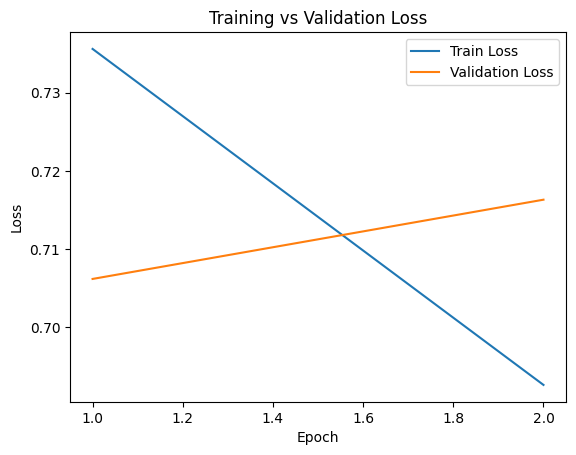

In [ ]:
import matplotlib.pyplot as plt

train_loss = [x[0] for x in hist['train']]
val_loss = [x[0] for x in hist['val']]
epochs = range(1, len(train_loss)+1)

plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [ ]:
%pip install facenet-pytorch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

In [ ]:
%pip install --upgrade numpy timm facenet-pytorch albumentations opencv-python scikit-learn matplotlib pandas tqdm Pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.2 MB/s eta 0:00:00
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 134.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 135.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 13.0 MB/s eta 0:00:00
  Attempting unins

In [ ]:
!pip install kaggle


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



In [ ]:
!kaggle datasets list -s "real and fake face detection"


ref                                                              title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
ciplab/real-and-fake-face-detection                              Real and Fake Face Detection                      452107760  2019-01-14 14:54:52.207000          30654        407  0.6875           
sachchitkunichetty/rvf10k                                        Real vs Fake Faces - 10k                          286539054  2024-03-09 19:24:25.637000           2476         37  0.88235295       
vbmokin/real-and-fake-face-detection-size-400x400                Real and Fake Face Detection - size 400x400        45759147  2023-02-15 01:50:26.070000            289         12  0.6875           
uditsharma

In [ ]:
!kaggle datasets download -d ciplab/real-and-fake-face-detection


Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
 96% 412M/431M [00:00<00:00, 481MB/s]
100% 431M/431M [00:00<00:00, 538MB/s]


In [ ]:
import zipfile

with zipfile.ZipFile("real-and-fake-face-detection.zip", "r") as zip_ref:
    zip_ref.extractall("/content/data/")


In [ ]:
DATASET_ROOT = "/content/data/real_and_fake_face"
REAL_PATH = f"{DATASET_ROOT}/training_real"
FAKE_PATH = f"{DATASET_ROOT}/training_fake"


In [ ]:
import shutil
import os
from sklearn.model_selection import train_test_split

# Define split paths
BASE_DIR = "/content/dataset_split"
TRAIN_DIR = f"{BASE_DIR}/train"
VAL_DIR = f"{BASE_DIR}/val"

for folder in [TRAIN_DIR, VAL_DIR]:
    os.makedirs(f"{folder}/real", exist_ok=True)
    os.makedirs(f"{folder}/fake", exist_ok=True)

# Get file lists
real_files = [os.path.join(REAL_PATH, f) for f in os.listdir(REAL_PATH)]
fake_files = [os.path.join(FAKE_PATH, f) for f in os.listdir(FAKE_PATH)]

# Train/val split (80% train, 20% val)
real_train, real_val = train_test_split(real_files, test_size=0.2, random_state=42)
fake_train, fake_val = train_test_split(fake_files, test_size=0.2, random_state=42)

# Copy files
def copy_files(files, destination):
    for file in files:
        shutil.copy(file, destination)

copy_files(real_train, f"{TRAIN_DIR}/real")
copy_files(real_val, f"{VAL_DIR}/real")
copy_files(fake_train, f"{TRAIN_DIR}/fake")
copy_files(fake_val, f"{VAL_DIR}/fake")

print("Training and validation folders are ready!")


Training and validation folders are ready!
